In [1]:
import numpy as np
import cv2
import cv2.data
import matplotlib.pyplot as plt
import os

In [2]:
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

image_path = "../../../Dane/Sample/zd"
files = [f for f in os.listdir(image_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG i PNG i WEBP

images = []

for file in files:
    img = cv2.imread(str(os.path.join(image_path, file)))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    images.append((img, file))

In [3]:
# Obliczenie kontekstu otoczenia twarzy
def get_face_context(img, face_coordinates):
    # 1. Obliczenie proporcji twarzy w stosunku do całego obrazu
    # 2. Obliczenie współrzędnych punktów w bezpośrednim otoczeniu twarzy
    # 3. Obliczenie współrzędnych punktów w dalszym otoczeniu twarzy
    # 4. Zwrócenie współrzędnych z funkcji
    x, y, w, h = face_coordinates
    img_h, img_w, _ = img.shape

    # Obliczenie proporcji twarzy w stosunku do całego obrazu
    face_proportion = (w * h) / (img_h * img_w)

    # Uznajemy, że bezpośrednie otoczenie twarzy to 40% wysokości i szerokości twarzy
    # [PARAMETR]
    context_proportion = 0.40

    # Obliczenie współrzędnych punktów w bezpośrednim otoczeniu twarzy
    rectangle_point = (x - (context_proportion * w), y - (context_proportion * h))
    rectangle_width = w + 2 * (context_proportion * w)
    rectangle_height = h + 2 * (context_proportion * h)

    # Obliczenie współrzędnych punktów w dalszym otoczeniu twarzy
    rectangle_point_far = (x - (2 * context_proportion * w), y - (2 * context_proportion * h))
    rectangle_width_far = w + 4 * (context_proportion * w)
    rectangle_height_far = h + 4 * (context_proportion * h)

    # Sprawdzenie, czy punkty nie wychodzą poza obraz
    if rectangle_point[0] < 0:
        rectangle_point = (0, rectangle_point[1])
    if rectangle_point[1] < 0:
        rectangle_point = (rectangle_point[0], 0)
    if rectangle_point[0] + rectangle_width > img_w:
        rectangle_width = img_w - rectangle_point[0]
    if rectangle_point[1] + rectangle_height > img_h:
        rectangle_height = img_h - rectangle_point[1]

    if rectangle_point_far[0] < 0:
        rectangle_point_far = (0, rectangle_point_far[1])
    if rectangle_point_far[1] < 0:
        rectangle_point_far = (rectangle_point_far[0], 0)
    if rectangle_point_far[0] + rectangle_width_far > img_w:
        rectangle_width_far = img_w - rectangle_point_far[0]
    if rectangle_point_far[1] + rectangle_height_far > img_h:
        rectangle_height_far = img_h - rectangle_point_far[1]

    # Zwrócenie wartości
    return {
        'face_proportion': face_proportion,
        'rectangle_point': rectangle_point,
        'rectangle_width': rectangle_width,
        'rectangle_height': rectangle_height,
        'rectangle_point_far': rectangle_point_far,
        'rectangle_width_far': rectangle_width_far,
        'rectangle_height_far': rectangle_height_far
    }

In [4]:
# Sprawdzany będzie tylko region wokół twarzy o podanej szerokości (w) i wysokości (h)
def calculate_edge_intensity(img_sobel, face_topleft, face_botright):
    # Uzyskanie regionu bez samej twarzy
    x1, y1 = face_topleft
    x2, y2 = face_botright
    # 1. [:y1, :] - górna część obrazu
    # 2. [y2:, :] - dolna część obrazu
    # 3. [y1:y2, :x1] - lewa część obrazu bez powtórzeń
    # 4. [y1:y2, x2:] - prawa część obrazu bez powtórzeń
    top = img_sobel[:y1, :]
    bottom = img_sobel[y2:, :]
    left = img_sobel[y1:y2, :x1]
    right = img_sobel[y1:y2, x2:]

    # Obliczenie intensywności krawędzi dla wszystkich regionów
    top_sum = np.sum(top)
    bottom_sum = np.sum(bottom)
    left_sum = np.sum(left)
    right_sum = np.sum(right)

    top_count = np.count_nonzero(top)
    bottom_count = np.count_nonzero(bottom)
    left_count = np.count_nonzero(left)
    right_count = np.count_nonzero(right)

    # Obliczenie średniej intensywności krawędzi
    avg_intensity = (top_sum + bottom_sum + left_sum + right_sum) / (top_count + bottom_count + left_count + right_count)

    return avg_intensity

In [5]:
for img, file in images:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Sobel
    faces = face_classifier.detectMultiScale(gray, 1.3, 5)
    if faces is None or len(faces) == 0:
        continue
    face = faces[0]
    face_context = get_face_context(img, face)
    
    img_copy = img.copy()
    
    # Twarz
    x, y, w, h = face
    
    # Bezpośrednie otoczenie twarzy
    rectangle_point = (int(face_context['rectangle_point'][0]), int(face_context['rectangle_point'][1]))
    rectangle_width = int(face_context['rectangle_width'])
    rectangle_height = int(face_context['rectangle_height'])
    
    # Dalsze otoczenie twarzy
    rectangle_point_far = (int(face_context['rectangle_point_far'][0]), int(face_context['rectangle_point_far'][1]))
    rectangle_width_far = int(face_context['rectangle_width_far'])
    rectangle_height_far = int(face_context['rectangle_height_far'])
    
    face_area = img_copy[y:y+h, x:x+w]
    context_area = img_copy[rectangle_point[1]:rectangle_point[1] + rectangle_height, rectangle_point[0]:rectangle_point[0] + rectangle_width]
    context_area_far = img_copy[rectangle_point_far[1]:rectangle_point_far[1] + rectangle_height_far, rectangle_point_far[0]:rectangle_point_far[0] + rectangle_width_far]
    
    face_area_gray = cv2.cvtColor(face_area, cv2.COLOR_RGB2GRAY)
    context_area_gray = cv2.cvtColor(context_area, cv2.COLOR_RGB2GRAY)
    context_area_far_gray = cv2.cvtColor(context_area_far, cv2.COLOR_RGB2GRAY)
    
    context_area_edges_x = cv2.Sobel(face_area_gray, cv2.CV_64F, 1, 0, ksize=3)
    context_area_edges_x = cv2.convertScaleAbs(context_area_edges_x)
    context_area_edges_y = cv2.Sobel(face_area_gray, cv2.CV_64F, 0, 1, ksize=3)
    context_area_edges_y = cv2.convertScaleAbs(context_area_edges_y)
    
    context_area_edges_x_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 1, 0, ksize=3)
    context_area_edges_x_far = cv2.convertScaleAbs(context_area_edges_x_far)
    context_area_edges_y_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 0, 1, ksize=3)
    context_area_edges_y_far = cv2.convertScaleAbs(context_area_edges_y_far)
    
    # plt.figure(figsize=(10, 10))
    # plt.subplot(1, 5, 1), plt.imshow(img_copy, cmap='gray'), plt.title("Original Image")
    # plt.subplot(1, 5, 2), plt.imshow(context_area_edges_x, cmap='gray'), plt.title("Sobel X close")
    # plt.subplot(1, 5, 3), plt.imshow(context_area_edges_y, cmap='gray'), plt.title("Sobel Y close")
    # plt.subplot(1, 5, 4), plt.imshow(context_area_edges_x_far, cmap='gray'), plt.title("Sobel X far")
    # plt.subplot(1, 5, 5), plt.imshow(context_area_edges_y_far, cmap='gray'), plt.title("Sobel Y far")
    # plt.show()

    # Porównanie intensywności krawędzi
    # Dla bliższego otoczenia:
    # gap_w = context_area_width - face_area_width / 2
    # gap_h = context_area_height - face_area_height / 2
    # face_topleft = (gap_w, gap_h)
    # face_botright = (gap_w + face_area_width, gap_h + face_area_height)
    gap_w = (context_area_gray.shape[1] - face_area_gray.shape[1]) // 2
    gap_h = (context_area_gray.shape[0] - face_area_gray.shape[0]) // 2
    face_topleft = (gap_w, gap_h)
    face_botright = (gap_w + face_area_gray.shape[1], gap_h + face_area_gray.shape[0])
    context_intensity_x = calculate_edge_intensity(context_area_edges_x, face_topleft, face_botright)
    context_intensity_y = calculate_edge_intensity(context_area_edges_y, face_topleft, face_botright)
    
    print("Plik:", file)
    
    print("Dla bliższego otoczenia:")
    print("Intensywność krawędzi w osi X:", context_intensity_x)
    print("Intensywność krawędzi w osi Y:", context_intensity_y)
    
    # Dla dalszego otoczenia:
    gap_w = (context_area_far_gray.shape[1] - face_area_gray.shape[1]) // 2
    gap_h = (context_area_far_gray.shape[0] - face_area_gray.shape[0]) // 2
    face_topleft = (gap_w, gap_h)
    face_botright = (gap_w + face_area_gray.shape[1], gap_h + face_area_gray.shape[0])
    context_far_intensity_x = calculate_edge_intensity(context_area_edges_x_far, face_topleft, face_botright)
    context_far_intensity_y = calculate_edge_intensity(context_area_edges_y_far, face_topleft, face_botright)
    
    print("Dla dalszego otoczenia:")
    print("Intensywność krawędzi w osi X:", context_far_intensity_x)
    print("Intensywność krawędzi w osi Y:", context_far_intensity_y)

Plik: 5.webp
Dla bliższego otoczenia:
Intensywność krawędzi w osi X: 56.40793489318413
Intensywność krawędzi w osi Y: 64.01748251748252
Dla dalszego otoczenia:
Intensywność krawędzi w osi X: 26.781857537980517
Intensywność krawędzi w osi Y: 33.02567242153381
Plik: 9.webp
Dla bliższego otoczenia:
Intensywność krawędzi w osi X: 38.09138840070299
Intensywność krawędzi w osi Y: 41.28936627282492
Dla dalszego otoczenia:
Intensywność krawędzi w osi X: 37.61718359873495
Intensywność krawędzi w osi Y: 36.90535498738066
Plik: 8.webp
Dla bliższego otoczenia:
Intensywność krawędzi w osi X: 43.45850229791836
Intensywność krawędzi w osi Y: 42.53151203678658
Dla dalszego otoczenia:
Intensywność krawędzi w osi X: 26.02346357063404
Intensywność krawędzi w osi Y: 30.590315629357335
Plik: 4.webp
Dla bliższego otoczenia:
Intensywność krawędzi w osi X: 50.293565683646115
Intensywność krawędzi w osi Y: 49.60315330426032
Dla dalszego otoczenia:
Intensywność krawędzi w osi X: 52.757030850519854
Intensywność 

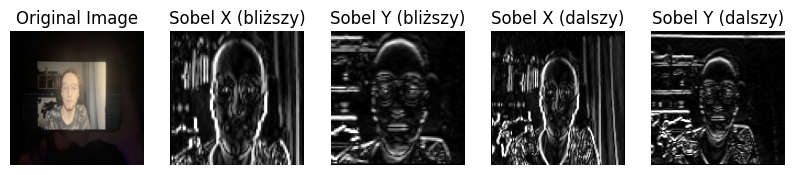

In [17]:
# Do pracy:
# Pokazanie tych, które znacznie odbiegają intensywnością
# Jakiś przykład podstawionej

img = cv2.cvtColor(cv2.imread("../../../Dane/Sample/context test 2.jpg"), cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Sobel
faces = face_classifier.detectMultiScale(gray, 1.3, 5)
face = faces[0]
face_context = get_face_context(img, face)

img_copy = img.copy()

# Twarz
x, y, w, h = face

# Bezpośrednie otoczenie twarzy
rectangle_point = (int(face_context['rectangle_point'][0]), int(face_context['rectangle_point'][1]))
rectangle_width = int(face_context['rectangle_width'])
rectangle_height = int(face_context['rectangle_height'])

# Dalsze otoczenie twarzy
rectangle_point_far = (int(face_context['rectangle_point_far'][0]), int(face_context['rectangle_point_far'][1]))
rectangle_width_far = int(face_context['rectangle_width_far'])
rectangle_height_far = int(face_context['rectangle_height_far'])

face_area = img_copy[y:y+h, x:x+w]
context_area = img_copy[rectangle_point[1]:rectangle_point[1] + rectangle_height, rectangle_point[0]:rectangle_point[0] + rectangle_width]
context_area_far = img_copy[rectangle_point_far[1]:rectangle_point_far[1] + rectangle_height_far, rectangle_point_far[0]:rectangle_point_far[0] + rectangle_width_far]

face_area_gray = cv2.cvtColor(face_area, cv2.COLOR_RGB2GRAY)
context_area_gray = cv2.cvtColor(context_area, cv2.COLOR_RGB2GRAY)
context_area_far_gray = cv2.cvtColor(context_area_far, cv2.COLOR_RGB2GRAY)

context_area_edges_x = cv2.Sobel(context_area_gray, cv2.CV_64F, 1, 0, ksize=3)
context_area_edges_x = cv2.convertScaleAbs(context_area_edges_x)
context_area_edges_y = cv2.Sobel(context_area_gray, cv2.CV_64F, 0, 1, ksize=3)
context_area_edges_y = cv2.convertScaleAbs(context_area_edges_y)

context_area_edges_x_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 1, 0, ksize=3)
context_area_edges_x_far = cv2.convertScaleAbs(context_area_edges_x_far)
context_area_edges_y_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 0, 1, ksize=3)
context_area_edges_y_far = cv2.convertScaleAbs(context_area_edges_y_far)

plt.figure(figsize=(10, 10))
plt.subplot(1, 5, 1), plt.imshow(img_copy, cmap='gray'), plt.title("Original Image"), plt.axis('off')
plt.subplot(1, 5, 2), plt.imshow(context_area_edges_x, cmap='gray'), plt.title("Sobel X (bliższy)"), plt.axis('off')
plt.subplot(1, 5, 3), plt.imshow(context_area_edges_y, cmap='gray'), plt.title("Sobel Y (bliższy)"), plt.axis('off')
plt.subplot(1, 5, 4), plt.imshow(context_area_edges_x_far, cmap='gray'), plt.title("Sobel X (dalszy)"), plt.axis('off')
plt.subplot(1, 5, 5), plt.imshow(context_area_edges_y_far, cmap='gray'), plt.title("Sobel Y (dalszy)"), plt.axis('off')
plt.axis('off')
plt.show()

gap_w = (context_area_gray.shape[1] - face_area_gray.shape[1]) // 2
gap_h = (context_area_gray.shape[0] - face_area_gray.shape[0]) // 2
face_topleft = (gap_w, gap_h)
face_botright = (gap_w + face_area_gray.shape[1], gap_h + face_area_gray.shape[0])
context_intensity_x = calculate_edge_intensity(context_area_edges_x, face_topleft, face_botright)
context_intensity_y = calculate_edge_intensity(context_area_edges_y, face_topleft, face_botright)

gap_w = (context_area_far_gray.shape[1] - face_area_gray.shape[1]) // 2
gap_h = (context_area_far_gray.shape[0] - face_area_gray.shape[0]) // 2
face_topleft = (gap_w, gap_h)
face_botright = (gap_w + face_area_gray.shape[1], gap_h + face_area_gray.shape[0])
context_far_intensity_x = calculate_edge_intensity(context_area_edges_x_far, face_topleft, face_botright)
context_far_intensity_y = calculate_edge_intensity(context_area_edges_y_far, face_topleft, face_botright)

In [18]:
print("Dla bliższego otoczenia:")
print("Intensywność krawędzi w osi X:", context_intensity_x)
print("Intensywność krawędzi w osi Y:", context_intensity_y)

print("Dla dalszego otoczenia:")
print("Intensywność krawędzi w osi X:", context_far_intensity_x)
print("Intensywność krawędzi w osi Y:", context_far_intensity_y)

Dla bliższego otoczenia:
Intensywność krawędzi w osi X: 48.62459336369551
Intensywność krawędzi w osi Y: 39.58359409924005
Dla dalszego otoczenia:
Intensywność krawędzi w osi X: 43.78142704655555
Intensywność krawędzi w osi Y: 35.9075382803298


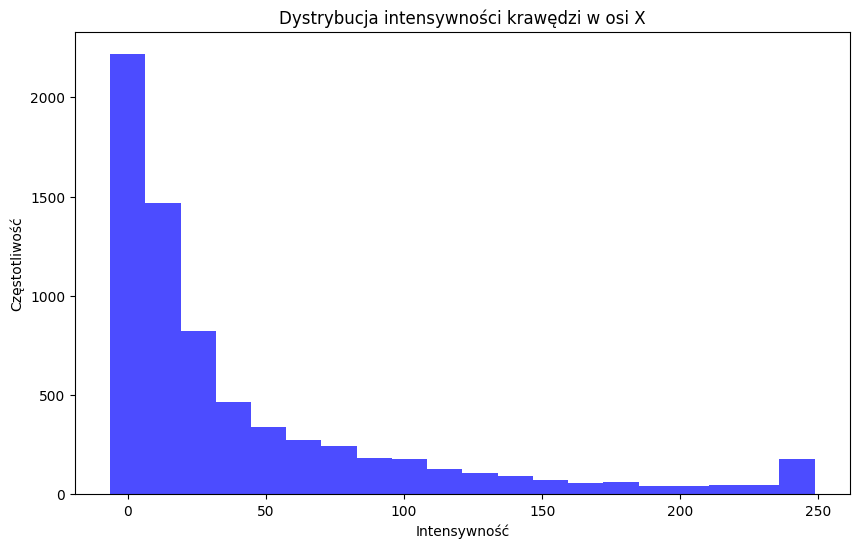

In [19]:
# Dodatek: analiza dystrybucji krawędzi
def analyze_edge_distribution(sobel):
    edge_data = sobel.flatten()

    # Utworzenie histogramu na podstawie intensywności krawędzi, podzielonego na 20 przedziałów
    # [PARAMETR]
    hist, bins = np.histogram(edge_data, bins=20)

    return hist, bins

# Dodatek: analiza dystrybucji krawędzi
histograms = []

hist, bins = analyze_edge_distribution(context_area_edges_x)
histograms.append(hist)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], hist, width=(bins[1] - bins[0]), color='b', alpha=0.7)
plt.xlabel("Intensywność")
plt.ylabel("Częstotliwość")
plt.title("Dystrybucja intensywności krawędzi w osi X")
plt.show()

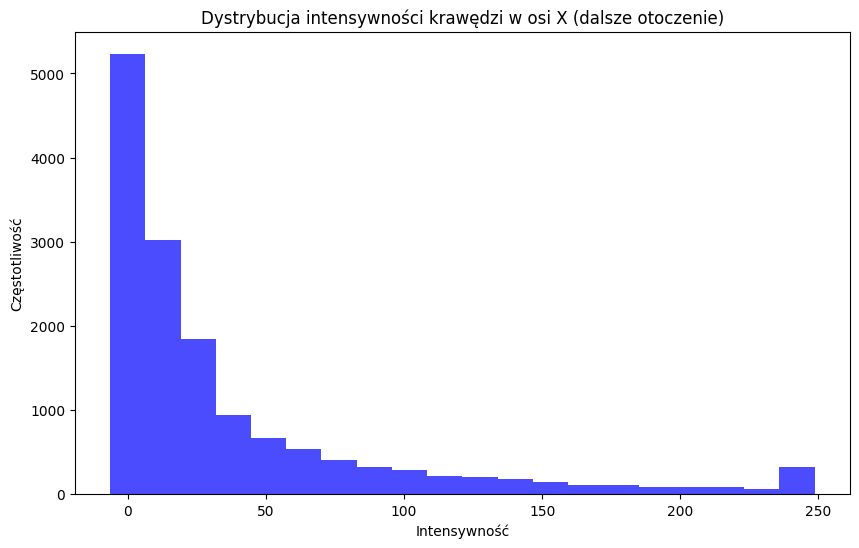

In [20]:
# Dodatek: analiza dystrybucji krawędzi
hist, bins = analyze_edge_distribution(context_area_edges_x_far)
histograms.append(hist)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], hist, width=(bins[1] - bins[0]), color='b', alpha=0.7)
plt.xlabel("Intensywność")
plt.ylabel("Częstotliwość")
plt.title("Dystrybucja intensywności krawędzi w osi X (dalsze otoczenie)")
plt.show()

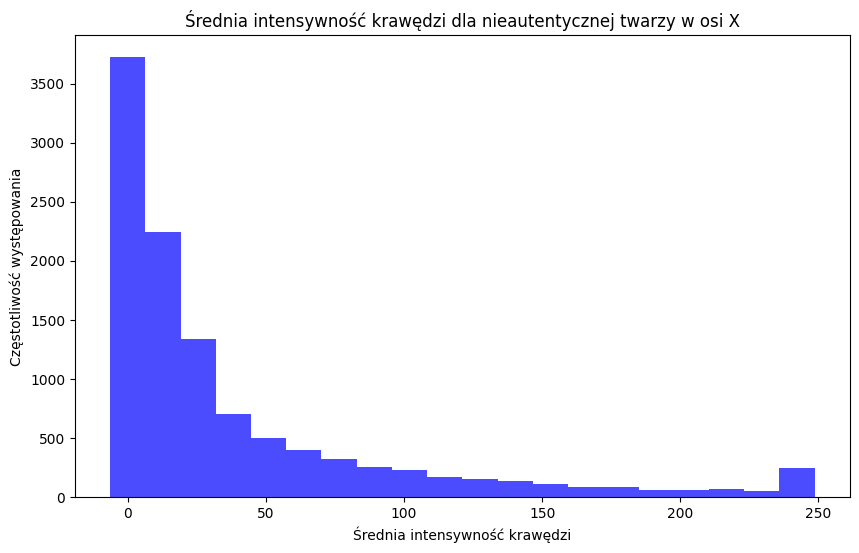

In [21]:
# Utworzenie "średniego" histogramu
def average_hist(histograms):
    hist_array = np.array(histograms)

    average_hist = np.mean(hist_array, axis=0)

    return average_hist

# Średni histogram dla tej nieautentycznej twarzy
avg_hist = average_hist(histograms)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], avg_hist, width=(bins[1] - bins[0]), color='b', alpha=0.7)
plt.xlabel("Średnia intensywność krawędzi")
plt.ylabel("Częstotliwość występowania")
plt.title("Średnia intensywność krawędzi dla nieautentycznej twarzy w osi X")
plt.show()

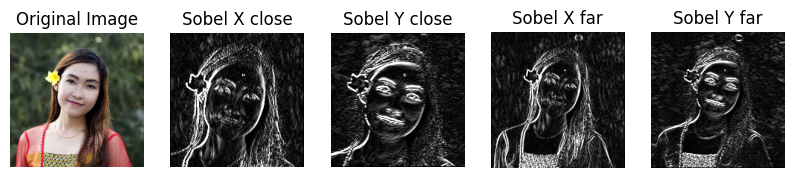

In [22]:
# Jakiś przykład niepodstawionej
# Do pracy:
# Pokazanie tych, które znacznie odbiegają intensywnością
# Jakiś przykład podstawionej

img = cv2.cvtColor(cv2.imread("../../../Dane/Sample/Default/1 (25).jpeg"), cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Sobel
faces = face_classifier.detectMultiScale(gray, 1.3, 5)
face = faces[0]
face_context = get_face_context(img, face)

img_copy = img.copy()

# Twarz
x, y, w, h = face

# Bezpośrednie otoczenie twarzy
rectangle_point = (int(face_context['rectangle_point'][0]), int(face_context['rectangle_point'][1]))
rectangle_width = int(face_context['rectangle_width'])
rectangle_height = int(face_context['rectangle_height'])

# Dalsze otoczenie twarzy
rectangle_point_far = (int(face_context['rectangle_point_far'][0]), int(face_context['rectangle_point_far'][1]))
rectangle_width_far = int(face_context['rectangle_width_far'])
rectangle_height_far = int(face_context['rectangle_height_far'])

face_area = img_copy[y:y+h, x:x+w]
context_area = img_copy[rectangle_point[1]:rectangle_point[1] + rectangle_height, rectangle_point[0]:rectangle_point[0] + rectangle_width]
context_area_far = img_copy[rectangle_point_far[1]:rectangle_point_far[1] + rectangle_height_far, rectangle_point_far[0]:rectangle_point_far[0] + rectangle_width_far]

# Przekonwertowanie wszystkich trzech obszarów na skalę szarości
face_area_gray = cv2.cvtColor(face_area, cv2.COLOR_RGB2GRAY)
context_area_gray = cv2.cvtColor(context_area, cv2.COLOR_RGB2GRAY)
context_area_far_gray = cv2.cvtColor(context_area_far, cv2.COLOR_RGB2GRAY)

# Operator Sobela dla bliższego otoczenia, dla osi X i Y, oraz przekonwertowanie z powrotem na zakres [0; 255]
context_area_edges_x = cv2.Sobel(context_area_gray, cv2.CV_64F, 1, 0, ksize=3)
context_area_edges_x = cv2.convertScaleAbs(context_area_edges_x)
context_area_edges_y = cv2.Sobel(context_area_gray, cv2.CV_64F, 0, 1, ksize=3)
context_area_edges_y = cv2.convertScaleAbs(context_area_edges_y)

# Operator Sobela dla dalszego otoczenia, dla osi X i Y, oraz przekonwertowanie z powrotem na zakres [0; 255]
context_area_edges_x_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 1, 0, ksize=3)
context_area_edges_x_far = cv2.convertScaleAbs(context_area_edges_x_far)
context_area_edges_y_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 0, 1, ksize=3)
context_area_edges_y_far = cv2.convertScaleAbs(context_area_edges_y_far)

plt.figure(figsize=(10, 10))
plt.subplot(1, 5, 1), plt.imshow(img_copy, cmap='gray'), plt.title("Original Image"), plt.axis('off')
plt.subplot(1, 5, 2), plt.imshow(context_area_edges_x, cmap='gray'), plt.title("Sobel X close"), plt.axis('off')
plt.subplot(1, 5, 3), plt.imshow(context_area_edges_y, cmap='gray'), plt.title("Sobel Y close"), plt.axis('off')
plt.subplot(1, 5, 4), plt.imshow(context_area_edges_x_far, cmap='gray'), plt.title("Sobel X far"), plt.axis('off')
plt.subplot(1, 5, 5), plt.imshow(context_area_edges_y_far, cmap='gray'), plt.title("Sobel Y far"), plt.axis('off')
plt.show()

gap_w = (context_area_gray.shape[1] - face_area_gray.shape[1]) // 2
gap_h = (context_area_gray.shape[0] - face_area_gray.shape[0]) // 2
face_topleft = (gap_w, gap_h)
face_botright = (gap_w + face_area_gray.shape[1], gap_h + face_area_gray.shape[0])
context_intensity_x = calculate_edge_intensity(context_area_edges_x, face_topleft, face_botright)
context_intensity_y = calculate_edge_intensity(context_area_edges_y, face_topleft, face_botright)

gap_w = (context_area_far_gray.shape[1] - face_area_gray.shape[1]) // 2
gap_h = (context_area_far_gray.shape[0] - face_area_gray.shape[0]) // 2
face_topleft = (gap_w, gap_h)
face_botright = (gap_w + face_area_gray.shape[1], gap_h + face_area_gray.shape[0])
context_far_intensity_x = calculate_edge_intensity(context_area_edges_x_far, face_topleft, face_botright)
context_far_intensity_y = calculate_edge_intensity(context_area_edges_y_far, face_topleft, face_botright)

In [23]:
print("Dla bliższego otoczenia:")
print("Intensywność krawędzi w osi X:", context_intensity_x)
print("Intensywność krawędzi w osi Y:", context_intensity_y)

print("Dla dalszego otoczenia:")
print("Intensywność krawędzi w osi X:", context_far_intensity_x)
print("Intensywność krawędzi w osi Y:", context_far_intensity_y)

Dla bliższego otoczenia:
Intensywność krawędzi w osi X: 40.25793357933579
Intensywność krawędzi w osi Y: 34.518977393555545
Dla dalszego otoczenia:
Intensywność krawędzi w osi X: 42.08622447053494
Intensywność krawędzi w osi Y: 34.569154266482634


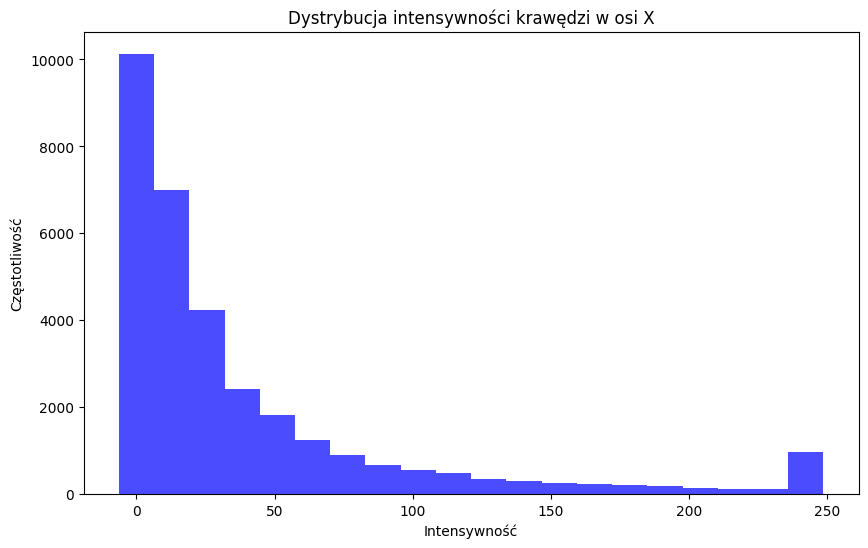

In [24]:
# Dodatek: analiza dystrybucji krawędzi
hist, bins = analyze_edge_distribution(context_area_edges_x)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], hist, width=(bins[1] - bins[0]), color='b', alpha=0.7)
plt.xlabel("Intensywność")
plt.ylabel("Częstotliwość")
plt.title("Dystrybucja intensywności krawędzi w osi X")
plt.show()

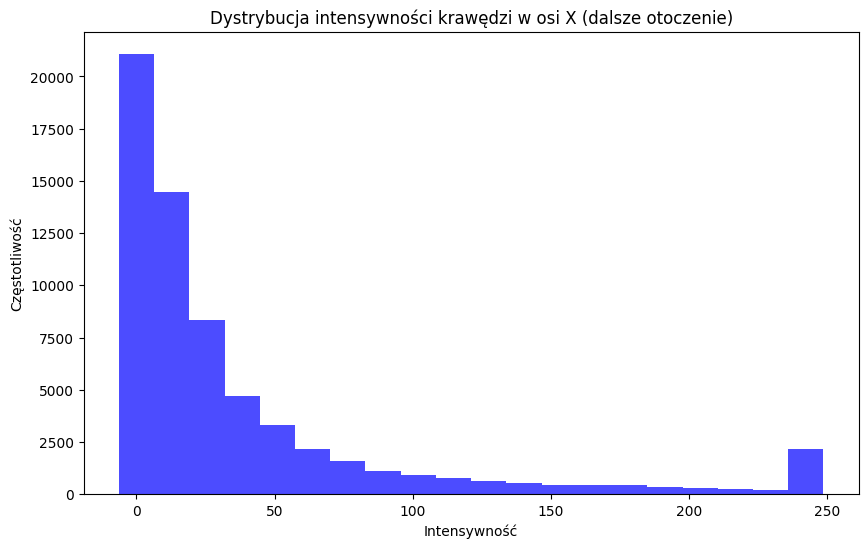

In [25]:
hist, bins = analyze_edge_distribution(context_area_edges_x_far)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], hist, width=(bins[1] - bins[0]), color='b', alpha=0.7)
plt.xlabel("Intensywność")
plt.ylabel("Częstotliwość")
plt.title("Dystrybucja intensywności krawędzi w osi X (dalsze otoczenie)")
plt.show()

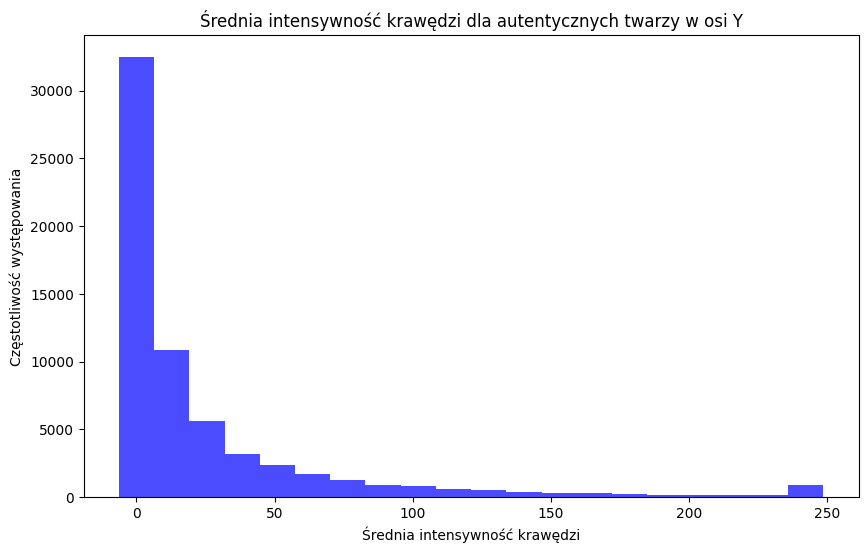

In [26]:
# Utworzenie "średniego" histogramu dla wszystkich autentycznych twarzy
# Wczytanie wszystkich autentycznych twarzy
image_path = "../../../Dane/Sample/Default"
files = [f for f in os.listdir(image_path) if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".jpeg")] # Tylko pliki JPG i PNG i JPEG

histograms = []

for file in files:
    img = cv2.cvtColor(cv2.imread(str(os.path.join(image_path, file))), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    faces = face_classifier.detectMultiScale(gray, 1.3, 5)
    if faces is None or len(faces) == 0:
        continue
    face = faces[0]
    face_context = get_face_context(img, face)

    img_copy = img.copy()

    x, y, w, h = face

    # Póki co tylko Sobel X
    rectangle_point = (int(face_context['rectangle_point'][0]), int(face_context['rectangle_point'][1]))
    rectangle_width = int(face_context['rectangle_width'])
    rectangle_height = int(face_context['rectangle_height'])

    rectangle_point_far = (int(face_context['rectangle_point_far'][0]), int(face_context['rectangle_point_far'][1]))
    rectangle_width_far = int(face_context['rectangle_width_far'])
    rectangle_height_far = int(face_context['rectangle_height_far'])

    context_area = img_copy[rectangle_point[1]:rectangle_point[1] + rectangle_height, rectangle_point[0]:rectangle_point[0] + rectangle_width]
    context_area_gray = cv2.cvtColor(context_area, cv2.COLOR_RGB2GRAY)
    context_area_far = img_copy[rectangle_point_far[1]:rectangle_point_far[1] + rectangle_height_far, rectangle_point_far[0]:rectangle_point_far[0] + rectangle_width_far]
    context_area_far_gray = cv2.cvtColor(context_area_far, cv2.COLOR_RGB2GRAY)

    context_area_edges_x = cv2.Sobel(context_area_gray, cv2.CV_64F, 0, 1, ksize=3)
    context_area_edges_x = cv2.convertScaleAbs(context_area_edges_x)
    
    context_area_edges_x_far = cv2.Sobel(context_area_far_gray, cv2.CV_64F, 0, 1, ksize=3)
    context_area_edges_x_far = cv2.convertScaleAbs(context_area_edges_x_far)

    hist, bins = analyze_edge_distribution(context_area_edges_x)
    histograms.append(hist)
    hist, bins = analyze_edge_distribution(context_area_edges_x_far)
    histograms.append(hist)
    
average_histogram = average_hist(histograms)

plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], average_histogram, width=(bins[1] - bins[0]), color='b', alpha=0.7)
plt.xlabel("Średnia intensywność krawędzi")
plt.ylabel("Częstotliwość występowania")
plt.title("Średnia intensywność krawędzi dla autentycznych twarzy w osi Y")
plt.show()